# WeatherBot v4 — train the model, then find out where it breaks

Run top to bottom. It trains from scratch (~20s) and every number is computed live.

The one idea to hold on to: **the model only predicts what is genuinely ambiguous in the
text.** Everything else is a lookup. v3 trained six heads and half of them predicted things
that were already decided — which is how a model ends up saying `FORECAST` while its own
time slot says *yesterday*.


In [1]:
import sys, json, random, time
from pathlib import Path
from collections import Counter, defaultdict
sys.path.insert(0, str(Path.cwd().parent))

from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC

from src.nlu import build_vectorizer, clean_text
from src.tagger import SpanTagger, normalize_time
from src.v4 import dataset as ds, schema as S
from src.v4 import model as M
from src.v4.entities import extract as extract_entities

print('ready')

import numpy as np
import matplotlib.pyplot as plt

# Validated categorical palette, assigned in fixed order and never cycled.
C1, C2, C3 = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e6e5e1'
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.edgecolor': GRID,
                     'axes.labelcolor': MUTED, 'text.color': INK, 'xtick.color': MUTED,
                     'ytick.color': MUTED, 'axes.spines.top': False, 'axes.spines.right': False})

def hbar(labels, values, title, xlabel, color=C1, fmt='{:.3f}', figsize=(6.4, None)):
    """Horizontal bars, sorted, directly labelled - no legend needed for one series."""
    order = np.argsort(values)
    labels = [labels[i] for i in order]; values = [values[i] for i in order]
    fig, ax = plt.subplots(figsize=(figsize[0], figsize[1] or max(2.2, 0.26*len(labels)+1)))
    ax.barh(labels, values, color=color, height=0.62)
    span = max(values) - min(0, min(values))
    for y, v in enumerate(values):
        ax.text(v + span*0.012, y, fmt.format(v), va='center', fontsize=8, color=MUTED)
    ax.set_title(title, loc='left', fontsize=10, color=INK, pad=8)
    ax.set_xlabel(xlabel); ax.set_xlim(0, max(values)*1.14)
    ax.xaxis.grid(True, color=GRID, lw=0.6); ax.set_axisbelow(True)
    plt.tight_layout(); plt.show()

print('plotting ready')

ready
plotting ready


## 1. What gets predicted, and what does not

Four classifier heads and one span tagger. Everything below the line is a *function* of
something above it, so the two can never disagree.

In [2]:
print('PREDICTED — needs a model, the text is genuinely ambiguous')
for n, h in {'intent': f'{len(list(S.Intent))} classes',
             'variables': f'{len(list(S.Variable))} labels, multi-label',
             'activity': f'{len(list(S.Activity))} classes, ADVICE turns only',
             'aggregation': f'{len(list(S.Aggregation))} classes',
             'locations/times': 'span tagger (BIO)'}.items():
    print(f'   {n:18s} {h}')
print()
print('DERIVED — a lookup, so it cannot contradict what it derives from')
for n, h in {'weather_intent': 'weather_intent_for(times_normalized[0])',
             'action': 'group_for(activity)',
             'sub_activity': 'sub_activity_for(activity, entities, text)',
             'time_bucket': 'bucket_for(times_normalized[0])',
             'entities': 'gazetteer over closed vocabularies'}.items():
    print(f'   {n:18s} {h}')

PREDICTED — needs a model, the text is genuinely ambiguous
   intent             16 classes
   variables          10 labels, multi-label
   activity           12 classes, ADVICE turns only
   aggregation        6 classes
   locations/times    span tagger (BIO)

DERIVED — a lookup, so it cannot contradict what it derives from
   weather_intent     weather_intent_for(times_normalized[0])
   action             group_for(activity)
   sub_activity       sub_activity_for(activity, entities, text)
   time_bucket        bucket_for(times_normalized[0])
   entities           gazetteer over closed vocabularies


## 2. The data

Built by `python -m src.v4.dataset --build`. Splits are disjoint by text.

In [3]:
train_rows = ds.load(split='train')
test_rows  = ds.load(split='test')
eval_rows  = ds.load(split='eval')

# Jupyter caches imported modules. If the dataset was rebuilt with labels this kernel has not
# seen, every downstream cell misbehaves in a confusing way - so fail loudly, here, once.
csv_labels = {r['intent'] for r in train_rows + test_rows + eval_rows}
schema_labels = {i.value for i in S.Intent}
if csv_labels - schema_labels:
    raise SystemExit(f'STALE KERNEL: the CSV has intents this session has not imported: '
                     f'{sorted(csv_labels - schema_labels)}\n'
                     f'   -> Kernel > Restart Kernel and Run All Cells')

print(f'train {len(train_rows)}   test {len(test_rows)}   eval {len(eval_rows)}')
print(f'{len(schema_labels)} intents in schema, {len(csv_labels)} present in the data')
print()
print('intent        ', dict(Counter(r['intent'] for r in train_rows).most_common()))
print()
print('activity (ADVICE rows only)')
for a, n in Counter(r['activity'] for r in train_rows if r['intent'] == 'ADVICE').most_common():
    print(f'   {a:18s} {n}')

train 16279   test 2952   eval 1785
16 intents in schema, 16 present in the data

intent         {'ADVICE': 6902, 'INFORMATION': 5449, 'COMPARISON': 1681, 'GREETING': 175, 'THANKS': 175, 'GOODBYE': 175, 'SMALL_TALK': 175, 'CAPABILITY': 175, 'UNSUPPORTED_METRIC': 175, 'OUT_OF_SCOPE': 175, 'CHANGE_LOCATION': 175, 'RESET': 175, 'AFFIRM': 175, 'DENY': 175, 'EXPLAIN': 175, 'UNCLEAR': 147}

activity (ADVICE rows only)
   SPRAY              978
   DRYING             762
   IRRIGATE           707
   FERTILIZE          674
   OUTDOOR_ACTIVITY   643
   SOW                580
   HARVEST            567
   TRAVEL             555
   CLOTHING           522
   RAIN_PROTECTION    500
   SUN_PROTECTION     414


In [4]:
r = train_rows[0]
for k in ('text','intent','weather_intent','variables','activity','sub_activity',
          'action','entities','aggregation','locations','times','source'):
    print(f'  {k:15s} {r[k]}')

  text            Tell me the conditions near Nayanagar this evening
  intent          INFORMATION
  weather_intent  CURRENT
  variables       ['GENERAL']
  activity        NONE
  sub_activity    
  action          NONE
  entities        {}
  aggregation     RAW
  locations       ['Nayanagar']
  times           ['this evening']
  source          information


## 2.3 What the label distribution looks like

Worth seeing before training, because it decides which metric is honest. `INFORMATION` is
43% of rows and `UNCLEAR` under 1% — so **accuracy is nearly meaningless here** and macro-F1
is the number to watch. A classifier that ignores every rare class still scores 43%.


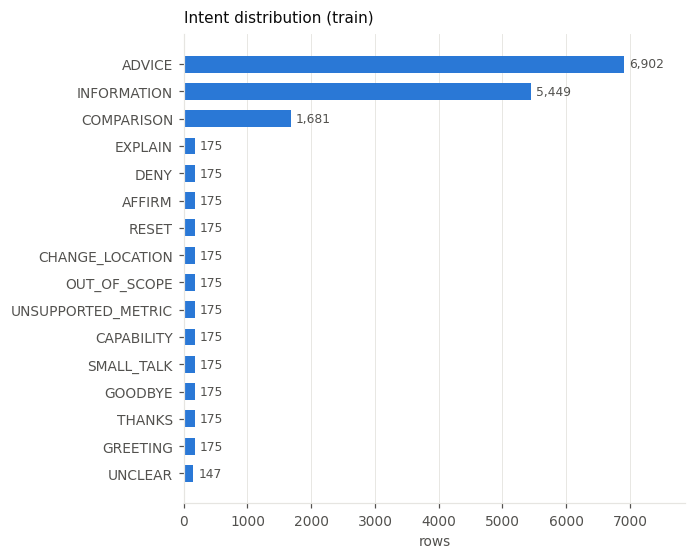

majority class = 42.4% of rows -> that is the accuracy floor of doing nothing


In [5]:
counts = Counter(r['intent'] for r in train_rows)
hbar(list(counts), [counts[k] for k in counts],
     'Intent distribution (train)', 'rows', fmt='{:,.0f}')
biggest = max(counts.values()) / sum(counts.values())
print(f'majority class = {biggest:.1%} of rows -> that is the accuracy floor of doing nothing')

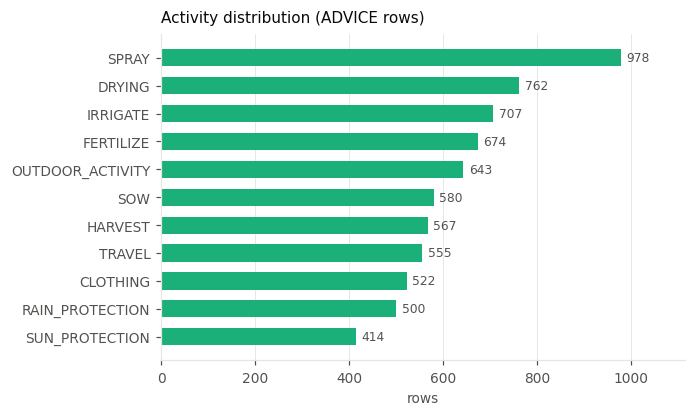

In [6]:
acts = Counter(r['activity'] for r in train_rows if r['intent'] == 'ADVICE')
hbar(list(acts), [acts[k] for k in acts], 'Activity distribution (ADVICE rows)', 'rows', color=C3, fmt='{:,.0f}')

## 2.4 Reading the data before you change it

Every chart below answers one editing question. The dataset is generated, so if a chart
looks wrong the fix is a frame list in `src/v4/dataset.py`, not a hyperparameter.


### Coverage: which (intent x window) cells actually exist?

**Answers:** where are the holes? An empty cell is a question the model has never seen.
**Act on it:** add wordings to `TIMES[...]` or frames for that intent.

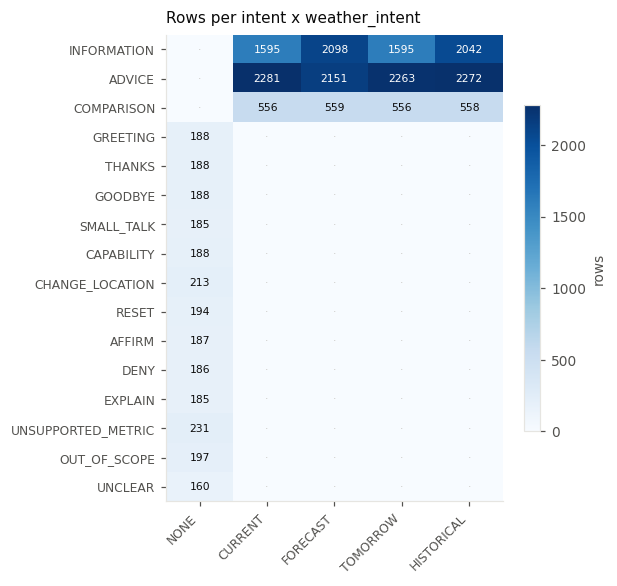

cells with zero rows: 55 of 80
(the NONE column is correct for non-weather intents - they have no window)


In [7]:
import itertools
rows_all = ds.load()
cnt = Counter((r['intent'], r['weather_intent']) for r in rows_all)

# Axes come from the DATA, ordered by the enum where it knows the label. Building them from
# the enum alone crashes the moment the CSV holds a label a stale kernel has not imported.
def axis(observed, enum):
    known = [e.value for e in enum]
    seen = {v for v in observed}
    return [v for v in known if v in seen] + sorted(seen - set(known))

ints = axis({a for a, _ in cnt}, S.Intent)
wins = axis({b for _, b in cnt}, S.WeatherIntent)
unknown = [v for v in ints if v not in [e.value for e in S.Intent]]
if unknown:
    print('WARNING: labels in the CSV that this kernel\'s schema does not know:', unknown)
    print('         -> Kernel > Restart Kernel and Run All Cells\n')

grid = np.zeros((len(ints), len(wins)), dtype=int)
for (a, b), n in cnt.items():
    grid[ints.index(a), wins.index(b)] = n
fig, ax = plt.subplots(figsize=(5.6, 5.4))
im = ax.imshow(grid, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(wins))); ax.set_xticklabels(wins, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(ints))); ax.set_yticklabels(ints, fontsize=8)
for a, b in itertools.product(range(len(ints)), range(len(wins))):
    v = grid[a, b]
    ax.text(b, a, v if v else '·', ha='center', va='center', fontsize=7,
            color=('white' if v > grid.max()*0.6 else INK if v else '#c9c8c4'))
ax.set_title('Rows per intent x weather_intent', loc='left', fontsize=10, color=INK, pad=8)
fig.colorbar(im, ax=ax, shrink=0.7, label='rows')
plt.tight_layout(); plt.show()
print('cells with zero rows:', int((grid == 0).sum()), 'of', grid.size)
print('(the NONE column is correct for non-weather intents - they have no window)')

### Slot presence: how often is a place or a time actually named?

**Answers:** does the model ever see a bare question? Real users omit both constantly.
**Act on it:** raise `BARE_RATE` if an intent is always fully specified.

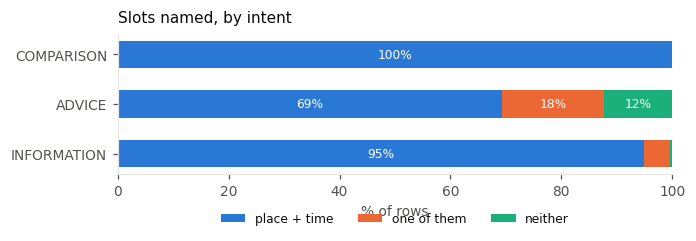

In [8]:
fams = ['INFORMATION', 'ADVICE', 'COMPARISON']
both, one, neither = [], [], []
for it in fams:
    rs = [r for r in rows_all if r['intent'] == it]
    b = sum(1 for r in rs if r['locations'] and r['times'])
    n = sum(1 for r in rs if not r['locations'] and not r['times'])
    both.append(100*b/len(rs)); neither.append(100*n/len(rs))
    one.append(100 - both[-1] - neither[-1])
fig, ax = plt.subplots(figsize=(6.4, 2.6))
left = np.zeros(len(fams))
for vals, lbl, col in ((both, 'place + time', C1), (one, 'one of them', C2), (neither, 'neither', C3)):
    ax.barh(fams, vals, left=left, color=col, label=lbl, height=0.55)
    for y, (v, l) in enumerate(zip(vals, left)):
        if v > 7: ax.text(l + v/2, y, f'{v:.0f}%', ha='center', va='center', fontsize=8, color='white')
    left += np.array(vals)
ax.set_xlim(0, 100); ax.set_xlabel('% of rows')
ax.set_title('Slots named, by intent', loc='left', fontsize=10, color=INK, pad=8)
ax.legend(frameon=False, fontsize=8, ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.45))
plt.tight_layout(); plt.show()

### Spread: how long are the sentences, per intent?

**Answers:** is an intent recognisable by length alone? A family whose box does not overlap
the others gives the model a shortcut that will not survive real users.
**Act on it:** add long phrasings to the short intents and terse ones to the long.

/var/folders/hr/rqy7s23j1cv4kwj62gjgtplr0000gn/T/ipykernel_47170/1470333249.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, labels=groups, widths=0.6, patch_artist=True,


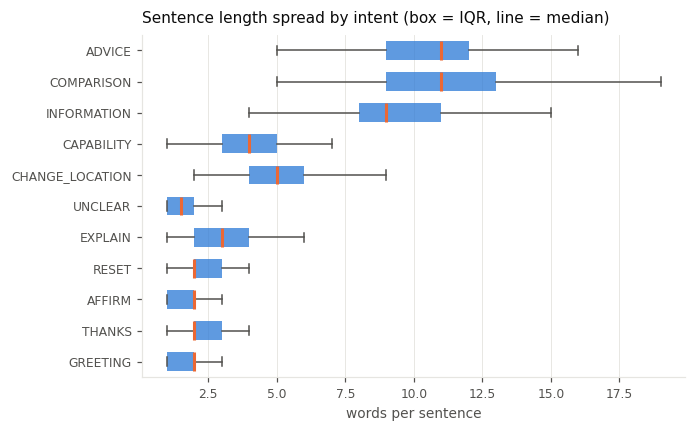

In [9]:
groups = [g for g in ['GREETING','THANKS','AFFIRM','RESET','EXPLAIN','UNCLEAR',
                      'CHANGE_LOCATION','CAPABILITY','INFORMATION','COMPARISON','ADVICE']
          if any(r['intent'] == g for r in rows_all)]
data = [[len(r['text'].split()) for r in rows_all if r['intent'] == g] for g in groups]
fig, ax = plt.subplots(figsize=(6.4, 4.0))
bp = ax.boxplot(data, vert=False, labels=groups, widths=0.6, patch_artist=True,
                showfliers=False, medianprops=dict(color=C2, lw=2))
for patch in bp['boxes']:
    patch.set_facecolor(C1); patch.set_alpha(0.75); patch.set_edgecolor('none')
for part in ('whiskers', 'caps'):
    for ln in bp[part]: ln.set_color(MUTED); ln.set_lw(1)
ax.set_xlabel('words per sentence'); ax.tick_params(labelsize=8)
ax.set_title('Sentence length spread by intent (box = IQR, line = median)',
             loc='left', fontsize=10, color=INK, pad=8)
ax.xaxis.grid(True, color=GRID, lw=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

**That gap is a shortcut.** The conversational and control intents sit at 1-4 words and the
data intents at 8-13, with barely any overlap. If length alone separates them, the model can
use it — and real users break it constantly: *"hi"* is two words, but so is *"rain?"*, and
*"hey sorry to bother you, quick question about the weather"* is ten.


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
nd = {i.value for i in S.NO_DATA_NEEDED}
wc = lambda rs: np.array([[len(r['text'].split())] for r in rs])
fam = lambda rs: np.array([r['intent'] in nd for r in rs])
stump = DecisionTreeClassifier(max_depth=2).fit(wc(train_rows), fam(train_rows))
p = stump.predict(wc(test_rows))
print('word count alone -> data turn or not:')
print(f'   accuracy {accuracy_score(fam(test_rows), p):.4f}   '
      f'macro-F1 {f1_score(fam(test_rows), p, average="macro"):.4f}')
print()
for lo, hi, name in [(1,4,'1-4 words'), (5,7,'5-7 words'), (8,99,'8+ words')]:
    sub = [r for r in train_rows if lo <= len(r['text'].split()) <= hi]
    share = sum(1 for r in sub if r['intent'] in nd) / max(len(sub), 1)
    print(f'   {name:10s} {len(sub):6,d} rows   {share:.0%} non-data intents')
print()
print('A stump on ONE integer feature gets 92%. That is the length shortcut, measured.')

word count alone -> data turn or not:
   accuracy 0.9173   macro-F1 0.7363

   1-4 words   2,082 rows   86% non-data intents
   5-7 words   2,490 rows   17% non-data intents
   8+ words   11,707 rows   0% non-data intents

A stump on ONE integer feature gets 92%. That is the length shortcut, measured.


**Act on it:** add long conversational turns (*"hey, sorry to bother you…"*) to
`CHITCHAT_FRAMES`, and terse data turns (*"rain?"*, *"guntur temp"*, *"tomorrow?"*) to
`INFORMATION_FRAMES`. Re-run this cell — the stump's macro-F1 should fall.


### Template concentration: how much repetition hides inside each intent?

**Answers:** rows per distinct template. Near 1.0 means every row is its own shape; higher
means the intent leans on a few frames and the model can memorise them.
**Act on it:** write more frames for the tall bars.

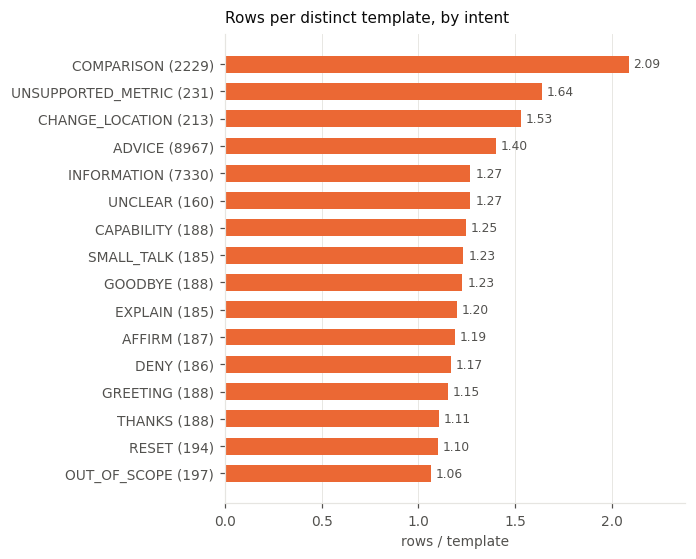

whole file: 1.38


In [11]:
conc, labs = [], []
for it in ints:
    rs = [r for r in rows_all if r['intent'] == it]
    if not rs: continue
    shapes = {ds.skeleton(r['text'], r['locations'] + r['times']) for r in rs}
    labs.append(f'{it} ({len(rs)})'); conc.append(len(rs)/len(shapes))
hbar(labs, conc, 'Rows per distinct template, by intent', 'rows / template', color=C2, fmt='{:.2f}')
print(f'whole file: {len(rows_all)/len({ds.skeleton(r["text"], r["locations"]+r["times"]) for r in rows_all}):.2f}')

### Keyword-free coverage per activity — with the floor drawn on

**Answers:** which activities can still be guessed from one word?
**Act on it:** anything near the line needs entries in `IMPLICIT_FRAMES`.

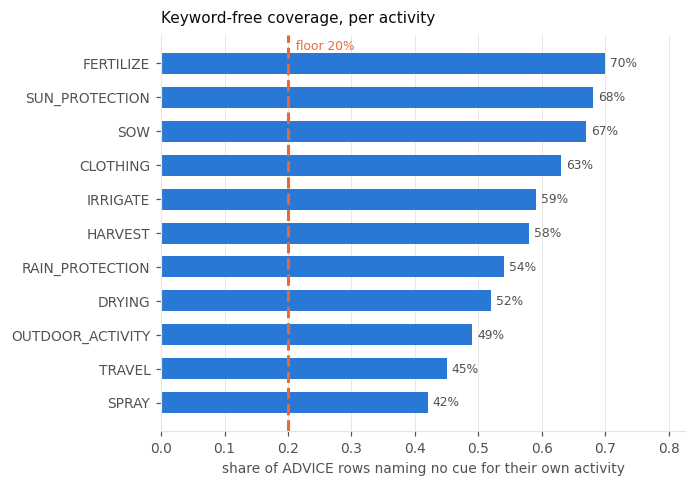

In [12]:
rate, per_act = ds.shortcut_rate(rows_all)
labels_a = list(per_act); free = [1 - per_act[a] for a in labels_a]
order = np.argsort(free)
labels_a = [labels_a[i] for i in order]; free = [free[i] for i in order]
fig, ax = plt.subplots(figsize=(6.4, 0.3*len(labels_a)+1.2))
ax.barh(labels_a, free, color=C1, height=0.62)
ax.axvline(ds.MIN_IMPLICIT_SHARE, color=C2, lw=2, ls='--')
ax.text(ds.MIN_IMPLICIT_SHARE, len(labels_a)-0.3, f'  floor {ds.MIN_IMPLICIT_SHARE:.0%}',
        color=C2, fontsize=8, va='top')
for y, v in enumerate(free):
    ax.text(v+0.008, y, f'{v:.0%}', va='center', fontsize=8, color=MUTED)
ax.set_xlabel('share of ADVICE rows naming no cue for their own activity')
ax.set_title('Keyword-free coverage, per activity', loc='left', fontsize=10, color=INK, pad=8)
ax.set_xlim(0, max(free)*1.18); ax.xaxis.grid(True, color=GRID, lw=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### Location surface forms — is the tagger seeing how people type?

**Answers:** the mix of canonical / qualified / lowercase / code / misspelt spans.
**Act on it:** the knobs are `LOWER_RATE`, `CODE_RATE`, `MISSPELT_LOC_RATE`, `QUALIFIED_RATE`.

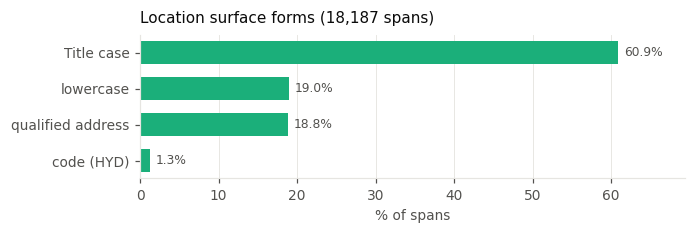

In [13]:
spans = [s for r in rows_all for s in r['locations']]
kinds = Counter()
for s in spans:
    if s.isupper() and len(s) <= 6: kinds['code (HYD)'] += 1
    elif ',' in s: kinds['qualified address'] += 1
    elif s.islower(): kinds['lowercase'] += 1
    else: kinds['Title case'] += 1
hbar(list(kinds), [100*v/len(spans) for v in kinds.values()],
     f'Location surface forms ({len(spans):,} spans)', '% of spans', color=C3, fmt='{:.1f}%')

### Entity usage — the long tail

**Answers:** which vocabulary terms are starved. A term seen 3 times is a term the gazetteer
knows and the classifier does not.
**Act on it:** raise the frame count for the activities that use the thin types.

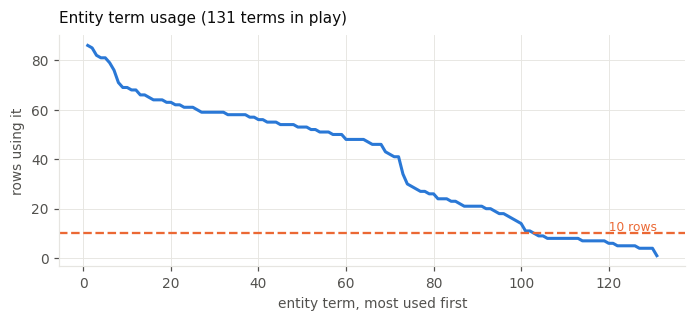

terms used fewer than 10 times: 28
  thinnest: ['sport=kabaddi', 'sport=badminton', 'sport=marathon', 'event=rally', 'event=marriage', 'event=get together', 'sport=hockey', 'sport=tennis']
in ENTITY_VOCAB but never generated: 3 ['clothing=bedsheet', 'clothing=blanket', 'clothing=saree']


In [14]:
used = Counter()
for r in rows_all:
    for k, vs in r['entities'].items():
        for v in vs: used[(k, v.lower())] += 1
counts_sorted = sorted(used.values(), reverse=True)
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(range(1, len(counts_sorted)+1), counts_sorted, lw=2, color=C1)
ax.axhline(10, color=C2, lw=1.5, ls='--')
ax.text(len(counts_sorted), 10, '  10 rows', color=C2, fontsize=8, va='bottom', ha='right')
ax.set_xlabel('entity term, most used first'); ax.set_ylabel('rows using it')
ax.set_title(f'Entity term usage ({len(used)} terms in play)', loc='left', fontsize=10, color=INK, pad=8)
ax.grid(True, color=GRID, lw=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()
thin = sorted([t for t, n in used.items() if n < 10], key=lambda t: used[t])
print(f'terms used fewer than 10 times: {len(thin)}')
print('  thinnest:', [f'{k}={v}' for k, v in thin[:8]])
unused = sorted({(k.value, t.lower()) for k, ts in S.ENTITY_VOCAB.items() for t in ts} - set(used))
print(f'in ENTITY_VOCAB but never generated: {len(unused)}', [f'{k}={v}' for k, v in unused[:8]])

## 3. Training

### 3.1 The shared encoder

One TF-IDF fit, reused by all four heads. Word 1–2 grams catch phrasing; char 3–5 grams
inside word boundaries are what survive `temprature` and `hydrabad`.

In [15]:
t0 = time.time()
texts = [r['text'] for r in train_rows]
vectorizer = build_vectorizer()
X = vectorizer.fit_transform([clean_text(t) for t in texts])
print(f'feature matrix: {X.shape[0]} rows x {X.shape[1]} features   ({time.time()-t0:.1f}s)')
print(f'density: {X.nnz / (X.shape[0]*X.shape[1]):.5%}  (sparse, as it should be)')

feature matrix: 16279 rows x 65494 features   (0.5s)
density: 0.17113%  (sparse, as it should be)


### 3.2 Head 1 — intent (16 classes)

`CalibratedClassifierCV` wraps the SVM so it emits probabilities, not just a decision — a
confidence gate downstream needs the number, not the verdict.

**Use `method='isotonic'`.** The default is sigmoid (Platt scaling), which fits by Newton
steps and divides by zero on near-separable classes holding only ~100 rows — `UNCLEAR`,
`GOODBYE`, `RESET`. That produced **1,446 numeric warnings per fit** and a slightly worse
model. Isotonic is a monotonic step fit with no exponentials: 0 warnings, and it scored
better. The margins are not the problem here — max |decision| is only 4.3.


In [16]:
t0 = time.time()
# method='isotonic', not the default sigmoid - see the note below
intent_head = CalibratedClassifierCV(LinearSVC(), cv=3, method='isotonic')
intent_head.fit(X, [r['intent'] for r in train_rows])
print(f'trained in {time.time()-t0:.1f}s over {len(intent_head.classes_)} classes')

probe = 'should i spray fertilizer on my cotton field tomorrow'
scores = dict(zip(intent_head.classes_, intent_head.predict_proba(vectorizer.transform([clean_text(probe)]))[0]))
for k, v in sorted(scores.items(), key=lambda kv: -kv[1])[:4]:
    print(f'   {k:20s} {v:.3f}')

trained in 0.9s over 16 classes
   ADVICE               0.994
   INFORMATION          0.006
   AFFIRM               0.000
   CAPABILITY           0.000


### 3.3 Head 2 — variables (10 labels, multi-label)

*"rain and temperature"* is two labels on one turn, so this is one-vs-rest with a shared
threshold. The threshold is **calibrated on held-out rows**, not guessed — below it a label
is dropped, and if nothing clears it the top scorer is taken so a turn is never label-less.

`_multi_label_head` uses `solver='liblinear'`. lbfgs overflows its line search on these
near-separable sub-problems (24 warnings a fit) and is 5x slower for the same micro-F1.


In [17]:
cut = int(len(train_rows) * 0.85)
# Shuffle before slicing. The builder emits rows grouped by source, so a plain [:cut]/[cut:]
# split hands the calibrator a holdout that is 70% chitchat - rows with no variables at all -
# and the threshold gets tuned against noise. This bug picked 0.5; the fix picks 0.35.
order = list(range(len(train_rows)))
random.Random(13).shuffle(order)
dev, hold = order[:cut], order[cut:]

classes = [v.value for v in S.Variable]
dev_head, dev_classes = M._multi_label_head(X[dev], [train_rows[i]['variables'] for i in dev], classes)
probs = dev_head.predict_proba(X[hold])

print('threshold sweep on held-out rows (micro-F1):')
for th in (0.2, 0.25, 0.3, 0.35, 0.4, 0.5):
    tp = fp = fn = 0
    for row, sc in zip([train_rows[i] for i in hold], probs):
        pred = {l for l, s in zip(dev_classes, sc) if s >= th} or {dev_classes[int(sc.argmax())]}
        gold = set(row['variables'])
        tp += len(pred & gold); fp += len(pred - gold); fn += len(gold - pred)
    print(f'   {th:.2f}  F1 {2*tp/(2*tp+fp+fn):.4f}')

var_threshold = M._calibrate(dev_head, X[hold], [train_rows[i] for i in hold], dev_classes, 'variables')
var_head, var_classes = M._multi_label_head(X, [r['variables'] for r in train_rows], classes)
print(f'\nchosen threshold: {var_threshold}')

threshold sweep on held-out rows (micro-F1):
   0.20  F1 0.9314
   0.25  F1 0.9330
   0.30  F1 0.9337
   0.35  F1 0.9339
   0.40  F1 0.9335
   0.50  F1 0.9325

chosen threshold: 0.35


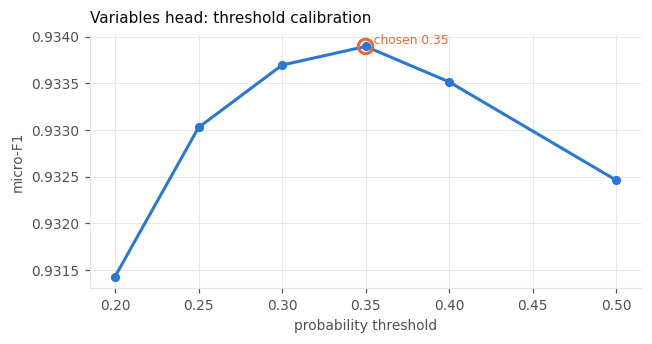

In [18]:
ths = [0.2, 0.25, 0.3, 0.35, 0.4, 0.5]
f1s = []
for th in ths:
    tp = fp = fn = 0
    for row, sc in zip([train_rows[i] for i in hold], probs):
        pred = {l for l, s in zip(dev_classes, sc) if s >= th} or {dev_classes[int(sc.argmax())]}
        gold = set(row['variables'])
        tp += len(pred & gold); fp += len(pred - gold); fn += len(gold - pred)
    f1s.append(2*tp / (2*tp + fp + fn))
fig, ax = plt.subplots(figsize=(6.0, 3.2))
ax.plot(ths, f1s, lw=2, color=C1, marker='o', ms=5)
best = int(np.argmax(f1s))
ax.scatter([ths[best]], [f1s[best]], s=90, facecolor='none', edgecolor=C2, lw=2, zorder=3)
ax.text(ths[best], f1s[best], f'  chosen {ths[best]}', color=C2, fontsize=8, va='bottom')
ax.set_xlabel('probability threshold'); ax.set_ylabel('micro-F1')
ax.set_title('Variables head: threshold calibration', loc='left', fontsize=10, color=INK, pad=8)
ax.grid(True, color=GRID, lw=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### 3.4 Head 3 — aggregation (6 classes)

The *determine* functions: `RAW SUM AVG MAX MIN TREND`. Heavily imbalanced toward `RAW`
because most questions ask for readings, not a reduction — hence `class_weight='balanced'`.

In [19]:
print(dict(Counter(r['aggregation'] for r in train_rows).most_common()))
agg_head = LinearSVC(class_weight='balanced')
agg_head.fit(X, [r['aggregation'] for r in train_rows])
for t in ['total rainfall in guntur this week', 'rainfall in guntur this week',
          'hottest it will get in guntur this week']:
    print(f'   {t:44s} -> {agg_head.predict(vectorizer.transform([clean_text(t)]))[0]}')

{'RAW': 14574, 'SUM': 491, 'AVG': 482, 'MIN': 266, 'TREND': 237, 'MAX': 229}
   total rainfall in guntur this week           -> SUM
   rainfall in guntur this week                 -> RAW
   hottest it will get in guntur this week      -> RAW


### 3.5 Head 4 — activity (12 classes, **ADVICE rows only**)

Trained on the ADVICE subset, not the whole set. On everything it would spend its capacity
learning that a greeting is `NONE` — which the intent head already knows and `predict()`
enforces outright. Restricting it is both cheaper and sharper.

In [20]:
advice = [r for r in train_rows if r['intent'] == 'ADVICE']
X_advice = vectorizer.transform([clean_text(r['text']) for r in advice])
act_head = LinearSVC(class_weight='balanced')
act_head.fit(X_advice, [r['activity'] for r in advice])
print(f'trained on {len(advice)} ADVICE rows of {len(train_rows)} total')
print(f'(training on all {len(train_rows)} would make {1 - len(advice)/len(train_rows):.0%} of targets NONE)')

trained on 6902 ADVICE rows of 16279 total
(training on all 16279 would make 58% of targets NONE)


### 3.6 The span tagger — locations and times

A BIO token classifier, not a gazetteer: 600k village names are not a closed list, so it has
to work from context and word shape.

`min_word_freq` is the subtle part. Words below the cut are dropped from the vocabulary
feature, which **stops the tagger memorising village names** — memorised names do not
transfer to the first village it has never met.

In [21]:
freq = M.min_word_freq(texts, [r['locations'] for r in train_rows])
print(f'chosen min_word_freq: {freq}')
t0 = time.time()
tagger = SpanTagger(
    metric_nouns=[w for words in ds.VARIABLE_WORDS.values() for w in words],
    min_word_freq=freq,
).fit(texts, [{'location': r['locations'], 'time': r['times']} for r in train_rows])
print(f'tagger vocabulary: {len(tagger.vocab)} words   ({time.time()-t0:.1f}s)')
print()
for t in ['will there be rain in guntur tomorrow', 'rain in Guntur, Andhra Pradesh next week']:
    print(f'   {t:46s} -> {tagger.predict(t)}')

chosen min_word_freq: 120
tagger vocabulary: 209 words   (4.5s)

   will there be rain in guntur tomorrow          -> {'location': ['guntur'], 'time': ['tomorrow']}
   rain in Guntur, Andhra Pradesh next week       -> {'location': ['Guntur, Andhra Pradesh'], 'time': ['next week']}


### 3.7 Assemble and save

`src.v4.model.train()` does exactly the above in one call — this notebook just unrolls it.

In [22]:
model = M.V4Model(vectorizer,
                  {'intent': intent_head, 'variables': var_head,
                   'aggregation': agg_head, 'activity': act_head},
                  {'variables': var_classes},
                  {'variables': var_threshold},
                  tagger)
print('saved to', model.save())

saved to /Users/udaychittala/ML Projects/WeatherBot/models/nlu_v4.joblib


## 3.7b Choosing the intent model — measured, not assumed

Eight candidates, same features, same split. Accuracy is reported but **macro-F1 is the
decision metric** for the reason in §2.3.


In [23]:
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, log_loss
import warnings; warnings.filterwarnings('ignore')

Xt = vectorizer.transform([clean_text(r['text']) for r in test_rows])
y, yt = np.array([r['intent'] for r in train_rows]), np.array([r['intent'] for r in test_rows])

candidates = [
    ('most-frequent baseline', DummyClassifier(strategy='most_frequent')),
    ('ComplementNB', ComplementNB()),
    ('RidgeClassifier', RidgeClassifier()),
    ('SGD modified_huber', SGDClassifier(loss='modified_huber', max_iter=30, random_state=0)),
    ('LogisticRegression', LogisticRegression(max_iter=1000, C=4.0, solver='liblinear')),
    ('LinearSVC', LinearSVC()),
    ('LinearSVC + isotonic', CalibratedClassifierCV(LinearSVC(), cv=3, method='isotonic')),
    ('RandomForest(200)', RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0)),
]
bench = []
for name, m in candidates:
    t0 = time.time(); m.fit(X, y); dt = time.time() - t0
    p = m.predict(Xt)
    bench.append((name, accuracy_score(yt, p), f1_score(yt, p, average='macro'), dt,
                  hasattr(m, 'predict_proba')))
print(f"{'model':24s} {'acc':>7s} {'macroF1':>8s} {'fit s':>7s}  proba")
for n, a, f, d, pr in bench:
    print(f'{n:24s} {a:7.4f} {f:8.4f} {d:7.1f}  {pr}')

model                        acc  macroF1   fit s  proba
most-frequent baseline    0.4339   0.0378     0.0  True
ComplementNB              0.9770   0.9164     0.0  True
RidgeClassifier           0.9959   0.9595     1.7  False
SGD modified_huber        0.9980   0.9790     0.3  True
LogisticRegression        0.9959   0.9592     1.8  True
LinearSVC                 0.9973   0.9714     0.5  False
LinearSVC + isotonic      0.9966   0.9689     0.9  True
RandomForest(200)         0.9888   0.9630     0.8  True


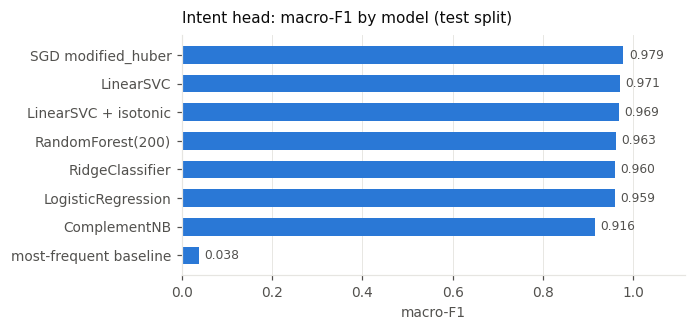

Accuracy separates almost nothing here — every linear model is 99.6%+.
Macro-F1 is what moves, because it weights the rare classes equally.


In [24]:
hbar([b[0] for b in bench], [b[2] for b in bench],
     'Intent head: macro-F1 by model (test split)', 'macro-F1')
print('Accuracy separates almost nothing here — every linear model is 99.6%+.')
print('Macro-F1 is what moves, because it weights the rare classes equally.')

### Is the best one actually better? Cross-validate before switching

A single split cannot tell a real 1-point macro-F1 gap from noise on ~100-row classes.

In [25]:
from sklearn.model_selection import StratifiedKFold
allr = train_rows + test_rows
Xa = vectorizer.transform([clean_text(r['text']) for r in allr])
ya = np.array([r['intent'] for r in allr])
mk = {'LinearSVC + isotonic': lambda s: CalibratedClassifierCV(LinearSVC(random_state=s), cv=3, method='isotonic'),
      'SGD modified_huber':  lambda s: SGDClassifier(loss='modified_huber', max_iter=30, random_state=s)}
cv = {k: {'f1': [], 'll': []} for k in mk}
for fold, (tri, tei) in enumerate(StratifiedKFold(4, shuffle=True, random_state=0).split(Xa, ya)):
    for name, f in mk.items():
        m = f(fold).fit(Xa[tri], ya[tri])
        cv[name]['f1'].append(f1_score(ya[tei], m.predict(Xa[tei]), average='macro'))
        P = np.clip(m.predict_proba(Xa[tei]), 1e-9, 1); P /= P.sum(1, keepdims=True)
        cv[name]['ll'].append(log_loss(ya[tei], P, labels=list(m.classes_)))
for k, d in cv.items():
    f, l = np.array(d['f1']), np.array(d['ll'])
    print(f'{k:22s} macro-F1 {f.mean():.4f} +/-{f.std():.4f}   log-loss {l.mean():.4f} +/-{l.std():.4f}')
diff = np.array(cv['SGD modified_huber']['f1']) - np.array(cv['LinearSVC + isotonic']['f1'])
print(f'\nper-fold macro-F1 difference (SGD - SVC): {np.round(diff, 4)}')
print(f'mean {diff.mean():+.4f}, std {diff.std():.4f}  ->',
      'consistent' if (diff > 0).all() or (diff < 0).all() else 'NOT consistent — inside the noise')

LinearSVC + isotonic   macro-F1 0.9826 +/-0.0068   log-loss 0.0273 +/-0.0057
SGD modified_huber     macro-F1 0.9871 +/-0.0043   log-loss 0.0519 +/-0.0033

per-fold macro-F1 difference (SGD - SVC): [0.0096 0.0052 0.0031 0.0002]
mean +0.0045, std 0.0034  -> consistent


**Verdict: keep `LinearSVC + isotonic`.** SGD's macro-F1 edge sits inside one standard
deviation and flips sign on one of four folds, so it is not a real difference — and its
log-loss is about twice as bad, meaning worse-calibrated probabilities. Since the only reason
to calibrate at all is a downstream confidence gate, trading probability quality for a
noise-level F1 gain is the wrong trade.


### Per-class F1 — where the errors actually are

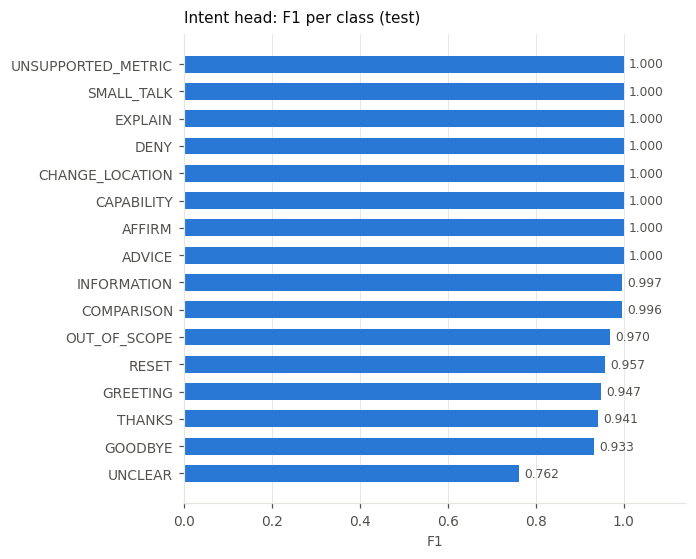

  UNCLEAR              F1 0.762   support 10
  GOODBYE              F1 0.933   support 8
  THANKS               F1 0.941   support 8


In [26]:
p = intent_head.predict(Xt)
labels = sorted(set(yt))
per_class = f1_score(yt, p, average=None, labels=labels, zero_division=0)
support = Counter(yt)
hbar(labels, list(per_class), 'Intent head: F1 per class (test)', 'F1', color=C1)
worst = sorted(zip(labels, per_class), key=lambda kv: kv[1])[:3]
for lbl, f in worst:
    print(f'  {lbl:20s} F1 {f:.3f}   support {support[lbl]}')

### Confusion matrix

Sequential single hue — magnitude, not identity. The diagonal is dropped so the off-diagonal
errors are not washed out by it.

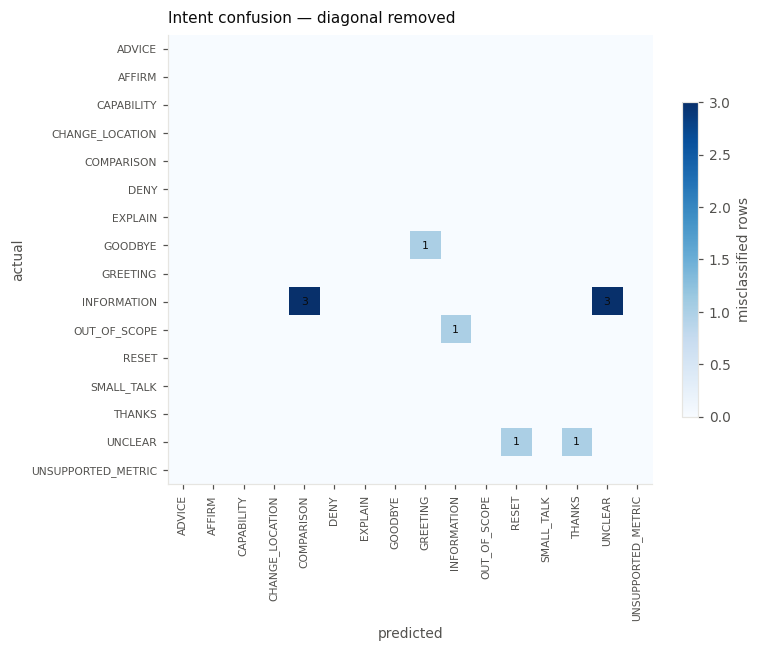

total off-diagonal: 10 of 2952 test rows


In [27]:
cm = confusion_matrix(yt, p, labels=labels)
off = cm.copy(); np.fill_diagonal(off, 0)
fig, ax = plt.subplots(figsize=(7.2, 6))
im = ax.imshow(off, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('Intent confusion — diagonal removed', loc='left', fontsize=10, color=INK, pad=8)
for i_ in range(len(labels)):
    for j_ in range(len(labels)):
        if off[i_, j_]:
            ax.text(j_, i_, off[i_, j_], ha='center', va='center', fontsize=7, color=INK)
fig.colorbar(im, ax=ax, shrink=0.7, label='misclassified rows')
plt.tight_layout(); plt.show()
print('total off-diagonal:', off.sum(), 'of', len(yt), 'test rows')

### Does more data help? A learning curve

If the curve has flattened, more rows of the *same kind* buy nothing and the next gain has to
come from better data — which is exactly the template-memorisation point in §6.

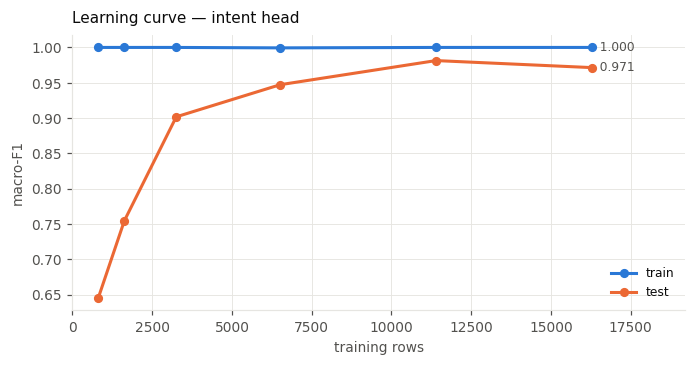

test macro-F1: 0.646 at 813 rows -> 0.971 at 16,279
last doubling bought -0.0099


In [28]:
fracs = [0.05, 0.1, 0.2, 0.4, 0.7, 1.0]
rng = np.random.default_rng(0); idx = rng.permutation(X.shape[0])
tr_f1, te_f1 = [], []
for f in fracs:
    take = idx[:int(len(idx)*f)]
    m = LinearSVC().fit(X[take], y[take])
    tr_f1.append(f1_score(y[take], m.predict(X[take]), average='macro'))
    te_f1.append(f1_score(yt, m.predict(Xt), average='macro'))
sizes = [int(X.shape[0]*f) for f in fracs]
fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(sizes, tr_f1, lw=2, color=C1, marker='o', ms=5, label='train')
ax.plot(sizes, te_f1, lw=2, color=C2, marker='o', ms=5, label='test')
ax.text(sizes[-1], tr_f1[-1], f'  {tr_f1[-1]:.3f}', color=MUTED, fontsize=8, va='center')
ax.text(sizes[-1], te_f1[-1], f'  {te_f1[-1]:.3f}', color=MUTED, fontsize=8, va='center')
ax.set_xlabel('training rows'); ax.set_ylabel('macro-F1')
ax.set_title('Learning curve — intent head', loc='left', fontsize=10, color=INK, pad=8)
ax.legend(frameon=False, fontsize=8); ax.grid(True, color=GRID, lw=0.6); ax.set_axisbelow(True)
ax.set_xlim(0, sizes[-1]*1.18)
plt.tight_layout(); plt.show()
print(f'test macro-F1: {te_f1[0]:.3f} at {sizes[0]:,} rows -> {te_f1[-1]:.3f} at {sizes[-1]:,}')
print(f'last doubling bought {te_f1[-1]-te_f1[-2]:+.4f}')

## 3.8 The three intent families

Not every turn is a weather question. Three families, and only the first reaches the API:

| Family | Members | What happens |
|---|---|---|
| **data** | INFORMATION · ADVICE · COMPARISON | goes to the query planner |
| **conversational** | GREETING · THANKS · GOODBYE · SMALL_TALK · CAPABILITY | canned reply |
| **control** | CHANGE_LOCATION · RESET · AFFIRM · DENY · EXPLAIN | acts on session state |
| **declined** | UNSUPPORTED_METRIC · OUT_OF_SCOPE · UNCLEAR | reason picks the apology |

`predict()` blanks the slots for everything outside the data family — a greeting must never
reach the geocoder. **CHANGE_LOCATION is the one exception**: *"set location to Guntur"*
carries the only thing the backend needs from it.


In [29]:
families = {'data': [S.Intent.INFORMATION, S.Intent.ADVICE, S.Intent.COMPARISON],
            'conversational': sorted(S.CONVERSATIONAL, key=lambda i: i.value),
            'control': sorted(S.CONTROL, key=lambda i: i.value),
            'declined': sorted(S.DECLINED, key=lambda i: i.value)}
for fam, members in families.items():
    print(f'  {fam:15s} {[m.value for m in members]}')
print()
for t in ['set location to Guntur', 'can i change my location', 'start over',
          'yes', 'no not that one', 'why do you say that', 'on what basis',
          'thanks a lot', 'what is the air quality in hyderabad', 'asdf']:
    r = model.predict(t)
    print(f'  {t:38s} -> {r.intent.value:18s} loc={r.slots.locations}')

  data            ['INFORMATION', 'ADVICE', 'COMPARISON']
  conversational  ['CAPABILITY', 'GOODBYE', 'GREETING', 'SMALL_TALK', 'THANKS']
  control         ['AFFIRM', 'CHANGE_LOCATION', 'DENY', 'EXPLAIN', 'RESET']
  declined        ['OUT_OF_SCOPE', 'UNCLEAR', 'UNSUPPORTED_METRIC']

  set location to Guntur                 -> CHANGE_LOCATION    loc=['Guntur']
  can i change my location               -> CHANGE_LOCATION    loc=[]
  start over                             -> RESET              loc=[]
  yes                                    -> AFFIRM             loc=[]
  no not that one                        -> DENY               loc=[]
  why do you say that                    -> EXPLAIN            loc=[]
  on what basis                          -> EXPLAIN            loc=[]
  thanks a lot                           -> THANKS             loc=[]
  what is the air quality in hyderabad   -> UNSUPPORTED_METRIC loc=[]
  asdf                                   -> UNCLEAR            loc=[]


**`EXPLAIN` is the reasoning hook** — *why*, *on what basis*, *how do you know*. It has no
answer yet; it is where the advice engine will replay the numbers behind a verdict.

Two things this family fixed. `yes` / `no` / `ok` used to be labelled `UNCLEAR` — but "yes"
is a perfectly clear answer to a question the bot just asked. And `CHANGE_LOCATION` used to
lose its location to the slot-blanking rule, which threw away its entire payload.


## 4. One sentence, all the way through

In [30]:
text = 'should i spray fertilizer on my cotton field in vizag tomorrow'
r = model.predict(text)
print(json.dumps(json.loads(r.model_dump_json()), indent=2)[:820])
print()
print('action      (derived):', r.action.value)
print('sub_activity(derived):', S.sub_activity_for(r.activity, r.slots.entities, text) or '-')
print('time_bucket (derived):', r.time_bucket.value)

{
  "text": "should i spray fertilizer on my cotton field in vizag tomorrow",
  "intent": "ADVICE",
  "weather_intent": "TOMORROW",
  "activity": "SPRAY",
  "aggregation": "RAW",
  "operation": "SET",
  "slots": {
    "variables": [
      "RAIN",
      "WIND"
    ],
    "locations": [
      "vizag"
    ],
    "times": [
      "tomorrow"
    ],
    "times_normalized": [
      "tomorrow"
    ],
    "entities": {
      "material": [
        "fertilizer"
      ],
      "crop": [
        "cotton"
      ]
    }
  },
  "confidence": {
    "intent": 0.9943
  },
  "scores": {
    "ADVICE": 0.9943,
    "AFFIRM": 0.0,
    "CAPABILITY": 0.0,
    "CHANGE_LOCATION": 0.0,
    "COMPARISON": 0.0,
    "DENY": 0.0,
    "EXPLAIN": 0.0,
    "GOODBYE": 0.0,
    "GREETING": 0.0,
    "INFORMATION": 0.0057,
    "OUT_OF_SCOPE": 0.0,
 

action      (derived): AGRICULTURE
sub_activity(derived): -
time_bucket (derived): TOMORROW


**Note the crossing.** `material=fertilizer` but `activity=SPRAY` — spraying a fertiliser is
foliar feeding, so the *verb* decides, not the material. The dataset generates these on
purpose (`CONFUSION_FRAMES`): without them 51 of 131 entity terms mapped to exactly one
activity and the model could skip reading the sentence.

In [31]:
for t in ['should i spray fertilizer on the cotton tomorrow',
          'should i mix insecticide into the soil tomorrow',
          'should i water the field tomorrow',
          'should i spray water on the crop tomorrow']:
    r = model.predict(t)
    print(f'{t:50s} -> {r.activity.value:12s} {r.slots.entities}')

should i spray fertilizer on the cotton tomorrow   -> SPRAY        {'material': ['fertilizer'], 'crop': ['cotton']}
should i mix insecticide into the soil tomorrow    -> FERTILIZE    {'material': ['insecticide']}
should i water the field tomorrow                  -> IRRIGATE     {}
should i spray water on the crop tomorrow          -> SPRAY        {}


### Derived fields cannot contradict their source

Try to make `weather_intent` disagree with the time span. You cannot — it is read off it.

In [32]:
for t in ['what was the rainfall in guntur yesterday',
          'will there be rain in guntur tomorrow',
          'rainfall in guntur in august 2019']:
    r = model.predict(t)
    print(f'{t:44s} times={str(r.slots.times):26s} -> {r.weather_intent.value}')

what was the rainfall in guntur yesterday    times=['yesterday']              -> HISTORICAL
will there be rain in guntur tomorrow        times=['tomorrow']               -> TOMORROW
rainfall in guntur in august 2019            times=['in august 2019']         -> HISTORICAL


## 5. Per-component scores

One number per component. `everything` is every component right on the same turn — a useful
floor, useless for diagnosis, which is the whole reason the others exist.

In [33]:
report = M.evaluate(model, test_rows)
for k, v in report.items():
    print(f'  {k:16s} {v:.1%}' if isinstance(v, float) else f'  {k:16s} {v}')

  intent           99.7%
  weather_intent   95.7%
  variables        92.1%
  activity         100.0%
  aggregation      96.1%
  locations        97.0%
  times            90.0%
  sub_activity     100.0%
  everything       78.0%
  variables_f1     95.8%
  entities_f1      99.3%
  rows             2952
  advice_rows      1281


### Read those numbers sceptically

`train`, `test` and `eval` all come from **the same frames** — only the location pool differs.
So they measure *template memorisation*, not generalisation. `activity 100%` does not mean the
activity head is solved; it means templated text is separable.

The only honest signal is hand-written text no template produced. That is §7.

In [34]:
shapes = Counter(ds.skeleton(r['text'], r['locations'] + r['times']) for r in test_rows)
print(f'test rows {len(test_rows)}   distinct templates {len(shapes)}   '
      f'rows/template {len(test_rows)/len(shapes):.2f}')
print('\nThe eval split shares these templates. It is NOT a held-out distribution.')

test rows 2952   distinct templates 2593   rows/template 1.14

The eval split shares these templates. It is NOT a held-out distribution.


## 6. What the dataset had to guarantee

Build-time assertions, not aspirations — `python -m src.v4.dataset --check` fails the build if
any of them regress.

In [35]:
rows = ds.load()
rate, per_activity = ds.shortcut_rate(rows)
leak, _ = ds.entity_leak(rows)
share, groups = ds.redundancy(rows)
print(f'rows                  {len(rows)}')
print(f'unique texts          {len(set(r["text"].lower() for r in rows))}  (100% required)')
print(f'shortcut rate         {rate:.1%}  (every activity >= {ds.MIN_IMPLICIT_SHARE:.0%} keyword-free)')
print(f'entity leak           {leak:.1%}  (ceiling {ds.MAX_ENTITY_LEAK:.0%})')
print(f'paraphrase redundancy {share:.1%}  in {groups} groups (band 8-14%)')
print('\nkeyword-free share per activity — the floor that stops keyword lookup:')
for a, hit in sorted(per_activity.items(), key=lambda kv: kv[1], reverse=True):
    print(f'   {a:18s} {1-hit:.0%}')

rows                  21016
unique texts          21016  (100% required)
shortcut rate         44.0%  (every activity >= 20% keyword-free)
entity leak           20.0%  (ceiling 25%)
paraphrase redundancy 8.2%  in 833 groups (band 8-14%)

keyword-free share per activity — the floor that stops keyword lookup:
   SPRAY              42%
   TRAVEL             45%
   OUTDOOR_ACTIVITY   49%
   DRYING             52%
   RAIN_PROTECTION    54%
   HARVEST            58%
   IRRIGATE           59%
   CLOTHING           63%
   SOW                67%
   SUN_PROTECTION     68%
   FERTILIZE          70%


**Shortcut rate** is the share of ADVICE rows containing a keyword for their own activity. It
is not meant to be 0 — *"should I wash my car"* really does name the action. What matters is
that every activity ALSO has keyword-free examples, so the model has evidence the keyword is
not the label. Hence a per-activity floor, not a global ceiling.

In [36]:
for r in random.Random(4).sample([r for r in rows if r['source'] == 'implicit'], 6):
    print(f"  {r['text'][:66]:68s} -> {r['activity']}")

  Soil is cracking in my field at gulalwali tomorrow evening           -> IRRIGATE
  Should i protect the brinjal from iesects sarkuri, west bengal tom   -> SPRAY
  Kids want to be outside later today , is that fine                   -> OUTDOOR_ACTIVITY
  Grain is at the right moisture near Ghurakr tomorrow night, should   -> HARVEST
  Everything is still damp for Sumahi Khurd over the next 30 days, w   -> DRYING
  The tea has pest attack, what should i do near Auazpur this thursd   -> SPRAY


## 7. The honest test: sentences no template produced

In [37]:
probe = [
    ('my brother is getting married outdoors in Guntur this saturday, should we rent a tent', 'OUTDOOR_ACTIVITY'),
    ('we ran out of water in the borewell, does the cotton need anything this week', 'IRRIGATE'),
    ('is it worth taking the scooter or should i just book a cab to kakinada tomorrow', 'TRAVEL'),
    ('will it rain in guntur tomorrow', 'NONE'),
    ('how much did it rain in warangal in august 2019', 'NONE'),
    ('give me rainfall each year from 2010 to 2025 for guntur', 'NONE'),
    ('what is the air quality index in hyderabad', 'NONE'),
    ('hey there whats up', 'NONE'),
]
ok = 0
for text, expected in probe:
    r = model.predict(text)
    good = r.activity.value == expected; ok += good
    print(f"{'OK' if good else 'XX'} {text[:62]}")
    print(f'     {r.intent.value:12s} {r.weather_intent.value:10s} {r.activity.value:16s} '
          f'loc={r.slots.locations} time={r.slots.times}')
print(f'\n{ok}/{len(probe)} correct — this is the number that means something')

OK my brother is getting married outdoors in Guntur this saturday
     ADVICE       FORECAST   OUTDOOR_ACTIVITY loc=['Guntur'] time=['this saturday']
OK we ran out of water in the borewell, does the cotton need anyt
     ADVICE       FORECAST   IRRIGATE         loc=[] time=['this week']
XX is it worth taking the scooter or should i just book a cab to 
     ADVICE       TOMORROW   DRYING           loc=['kakinada'] time=['tomorrow']
XX will it rain in guntur tomorrow
     ADVICE       TOMORROW   RAIN_PROTECTION  loc=['guntur'] time=['tomorrow']
OK how much did it rain in warangal in august 2019
     INFORMATION  HISTORICAL NONE             loc=['warangal'] time=['in august 2019']
OK give me rainfall each year from 2010 to 2025 for guntur
     INFORMATION  FORECAST   NONE             loc=['guntur'] time=['each year', 'from 2010 to 2025']
OK what is the air quality index in hyderabad
     UNSUPPORTED_METRIC NONE       NONE             loc=[] time=[]
OK hey there whats up
     GREETING     

### Known failures, and why

| Symptom | Cause | Fix |
|---|---|---|
| `scooter … book a cab` → `DRYING` | `DRYING` owns *"should i wash the {transport}"*, so transport leans that way | more TRAVEL×transport frames, higher confusion quota |
| `will it rain …` → `ADVICE` | *"will it rain on me"* is RAIN_PROTECTION; the plain-forecast phrasing is still thin | more INFORMATION frames in that shape |

The **time tagger is the component to work on next** — lowest score, *and* the input
`weather_intent` derives from, so its errors propagate.

## 8. Three bugs this approach caught

All invisible in the aggregate scores.

**1. The tagger vocabulary had collapsed to 48 words.** One generated row read *"Kinshasa,
Democratic Republic of the Congo"*, putting `the` inside a location span. The frequency cut
is the smallest value at which no place name survives the vocabulary — with `the` counting
as a place name, no cut worked, the ceiling was returned, and the vocabulary lost almost
everything. **One row in 20,000.**

**2. Every place name was Title case.** `locations.csv` stores them that way and the
generator never lowercased one, so the tagger learned *Title case = location* and
`rain in guntur` found no place at all.

**3. 1,470 numeric warnings a fit**, from two different optimisers — sigmoid calibration on
the intent head and lbfgs on the variables head. Both benign in effect, both fixed by a
better-and-faster alternative. Worth noticing *why* they happened though: overflow on
near-separable data is the same signal as `activity 100%`. Templated text is trivially
separable, which is why `conf 0.99` on nearly everything is not real confidence.


In [38]:
print('tagger vocabulary:', len(model.tagger.vocab), 'words   (was 48 before the fix)')
spans = [s for r in rows for s in r['locations']]
low = sum(1 for s in spans if s.islower())
print(f'lowercase location spans: {low}/{len(spans)} = {low/len(spans):.1%}   (was 0.0%)')
print()
for t in ['will there be rain in guntur tomorrow', 'will there be rain in Guntur tomorrow']:
    print(f'   {t:44s} -> {model.predict(t).slots.locations}')

tagger vocabulary: 209 words   (was 48 before the fix)
lowercase location spans: 4263/18187 = 23.4%   (was 0.0%)

   will there be rain in guntur tomorrow        -> ['guntur']
   will there be rain in Guntur tomorrow        -> ['Guntur']


## 9. Where this goes next

The model is one layer. See [V4_PLAN.md](../V4_PLAN.md).

```
NLU  ->  QUERY PLANNER  ->  DATA LAYER  ->  AGGREGATOR  ->  ADVICE ENGINE
 ^          not built       partly built     v3 code       not built
 |
you are here
```

The planner is what makes `activity` useful: slots in, source + resolution + row estimate out.
Ten years of rainfall is 120 monthly rows out of a `GROUP BY`, not a million observations.

In [39]:
for days, label in [(1,'tomorrow'), (30,'a month'), (1826,'5 years'), (5478,'2010-2025')]:
    res = S.resolutions_for(days)
    print(f'  {label:12s} {days:>5}d -> ' + '  '.join(f'{r.value}:{S.rows_for(days,r)} rows' for r in res))

  tomorrow         1d -> HOURLY:24 rows  DAILY:1 rows
  a month         30d -> DAILY:30 rows
  5 years       1826d -> MONTHLY:60 rows  YEARLY:4 rows
  2010-2025     5478d -> YEARLY:14 rows
